# AdventureWorks Försäljningsanalys
I denna analys undersöker vi AdventureWorks-databasen för att besvara affärsfrågor som exempelvis:
- Produktkategorier och deras försäljning
- Försäljningstrender över tid
- Regional försäljning

Vi använder SQL för att hämta data och Python för visualisering och analys

In [24]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus


user = "SA"
password = "hiTTanemo2"
server = "localhost,1433"
database = "AdventureWorks2025"
driver = quote_plus("ODBC Driver 18 for SQL Server")

connection_string = (
    f"mssql+pyodbc://{user}:{password}@{server}/{database}"
    f"?driver={driver}&Encrypt=yes&TrustServerCertificate=yes"
)

engine = create_engine(connection_string)


try:
    with engine.connect():
        print("Anslutning till SQL Server lyckades")
except Exception as e:
    print("Kunde inte ansluta", e)


Anslutning till SQL Server lyckades


C:\Users\veras\AppData\Local\Temp\ipykernel_26232\2276344209.py:24: SAWarning: Unrecognized server version info '17.0.1000.7'.  Some SQL Server features may not function properly.
  with engine.connect():


In [25]:
def query_df(sql: str):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

## Visualisering 1: Antal produkter per kategori
Hur många produkter finns i varje kategori?

Tabeller som används:
Production.ProductCategory    
Production.ProductSubcategory   
Production.Product   

Plan:
JOINA tabellerna    
Räkna DISTINCT produkter per kategori   
Skapa vertikalt stapeldiagram    
Analysera resultatet

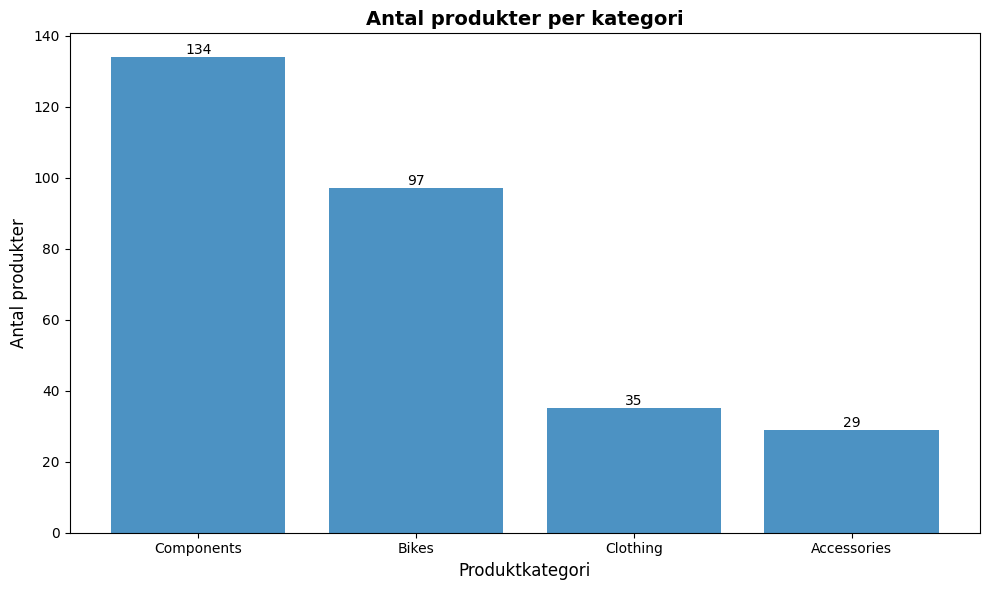

In [26]:
query_vis1 = """
SELECT 
    pc.Name AS CategoryName,
    COUNT(DISTINCT p.ProductID) AS ProductCount
FROM Production.ProductCategory pc
INNER JOIN Production.ProductSubcategory psc ON pc.ProductCategoryID = psc.ProductCategoryID
INNER JOIN Production.Product p ON psc.ProductSubcategoryID = p.ProductSubcategoryID
GROUP BY pc.Name 
ORDER BY ProductCount DESC
"""

df_vis1 = query_df(query_vis1)


fig, ax = plt.subplots(figsize=(10,6))
bars = ax.bar(df_vis1['CategoryName'], df_vis1['ProductCount'], alpha=0.8)
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom'
    )
ax.set_xlabel('Produktkategori', fontsize=12)
ax.set_ylabel('Antal produkter', fontsize=12)
ax.set_title('Antal produkter per kategori', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



### Insikter - Antal produkter per kategori
Components är störst kategorin med 134 produkter   
Accessories är minst med 29 produkter    


Detta indikerar på att företaget är stakt fokuserat på komponenter och reservdelar. Även att assessories kan vara ett utvecklingsområde. 

## Visualisering 2: Försäljning per produktkategori
Vilken produktkategori genererar mest intäkter?

Tabeller som används:
Production.ProductCategory    
Production.ProductSubcategory   
Production.Product   
Sales.SalesOrderDetail

Plan:
JOINA tabellerna    
Räkna SUM intäkter per kategori   
Skapa horisontellt stapeldiagram    
Analysera resultatet

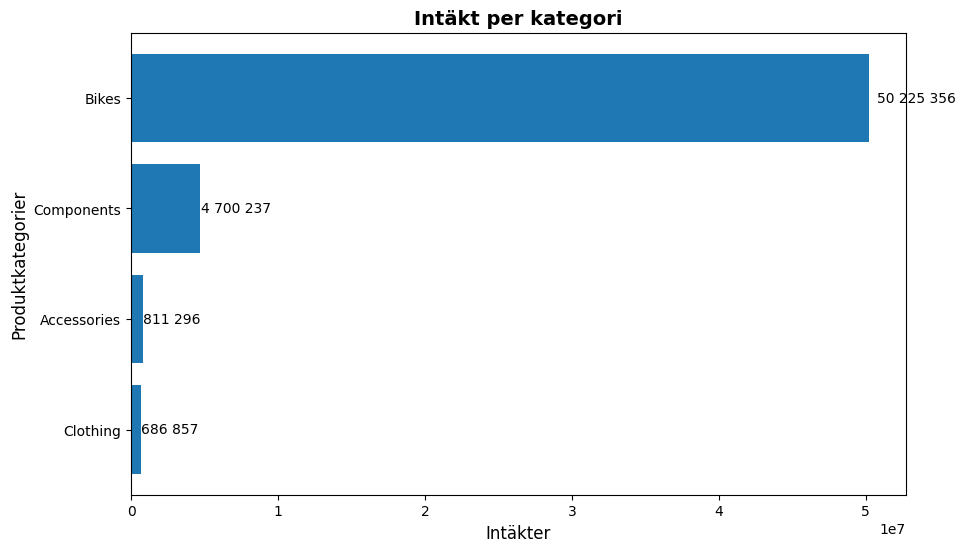

In [27]:
query_vis2 = """
SELECT 
    pc.Name AS CategoryName,
    SUM(sod.UnitPrice) AS Revenue
FROM Production.ProductCategory pc
INNER JOIN Production.ProductSubcategory psc ON pc.ProductCategoryID = psc.ProductCategoryID
INNER JOIN Production.Product p ON psc.ProductSubcategoryID = p.ProductSubcategoryID
INNER JOIN Sales.SalesOrderDetail sod ON p.ProductID = sod.ProductID
GROUP BY pc.Name
ORDER BY Revenue ASC
"""

df_vis2 = query_df(query_vis2)


fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(df_vis2['CategoryName'], df_vis2['Revenue'])
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + width * 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}'.replace(',', ' '),
        va='center'
    )
ax.set_xlabel('Intäkter', fontsize=12)
ax.set_ylabel('Produktkategorier', fontsize=12)
ax.set_title('Intäkt per kategori', fontsize=14, fontweight='bold')
plt.show()




### Insikter - Intäkter per kategori
Bikes är kategorin med störst intäkter med 50 224 365 kr     
Clothing har minst intäkter med 686 857 kr   


Detta visar tydligt att företagets störst inkomstkälla är cyklar.

## Visualisering 3: Försäljningstrend över tid
Hur har försäljningen utvecklats över tid?

Tabell som används: 
Sales.SalesOrderHeader

Plan:  
Aggregera OrderDate på månadsnivå     
Räkna SUM intäkter per månad   
Skapa linjediagram   
Analysera resultatet

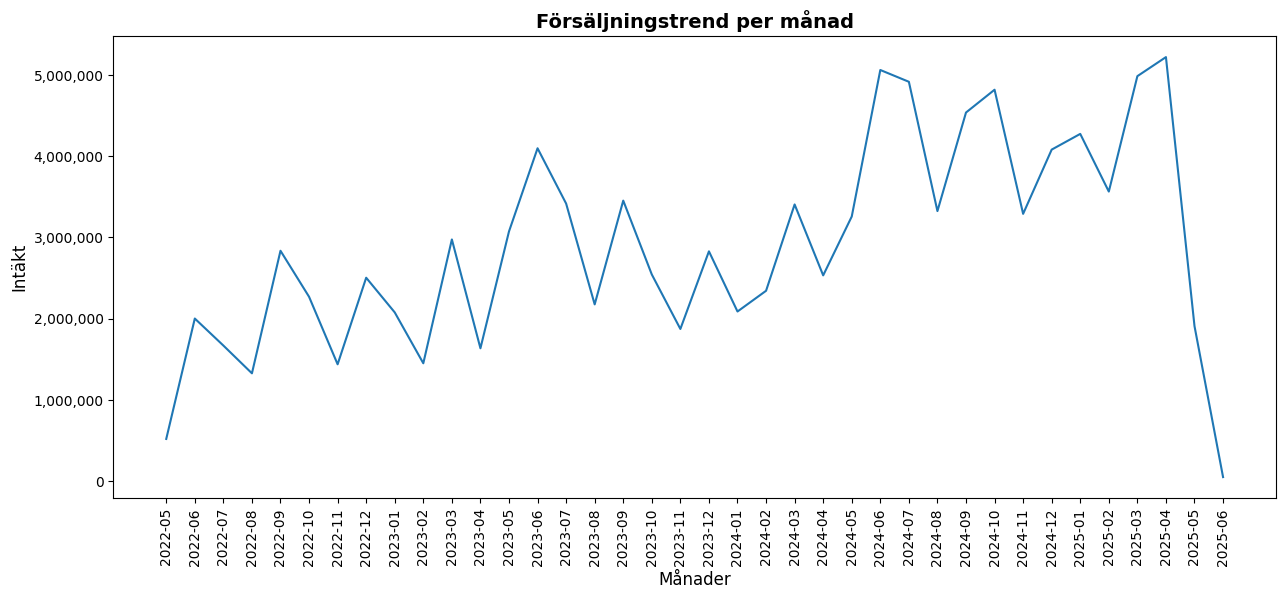

In [28]:
query_vis3 = """
SELECT 
    FORMAT(OrderDate, 'yyyy-MM') AS Months,
    SUM(SubTotal) AS Revenue
FROM Sales.SalesOrderHeader
GROUP BY FORMAT(OrderDate, 'yyyy-MM')
ORDER BY Months
"""
df_vis3 = query_df(query_vis3)

fig, ax = plt.subplots(figsize=(15,6))
ax.plot(df_vis3['Months'], df_vis3['Revenue'])
ax.yaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:,.0f}')
)
ax.set_xlabel('Månader', fontsize=12)
ax.set_ylabel('Intäkt', fontsize=12)
ax.set_title('Försäljningstrend per månad', fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.show()

### Insikter - Försäljningstrend över tid
Försäljningen ökar över tid. Det finns tecken på säsongsvariation där försäljningen ser ut att öka cirka var tredje månad. 

Den högsta försäljning noteras under april 2025, strax över 5 miljoner. 
Försäljning går ner under 2025-05 och 2025-06 men beror sannolikt på ofullstädig data för de månaderna snarare än en sån kraftig nedgång. Om man bortser från dessa månader noteras den lägsta intänkten vid maj 2022, strax över 0.5 miljoner.



## Visualisering 4: Försäljning och antal ordrar per år
Hur ser total försäljning och antal ordrar ut per år?

Tabell som används: 
Sales.SalesOrderHeader

Plan:  
Aggregera OrderDate på årsnivå    
Räkna SUM intäkter
Räkna antal ordrar   
Skapa stapeldiagram med två y-axlar  
Analysera resultatet 

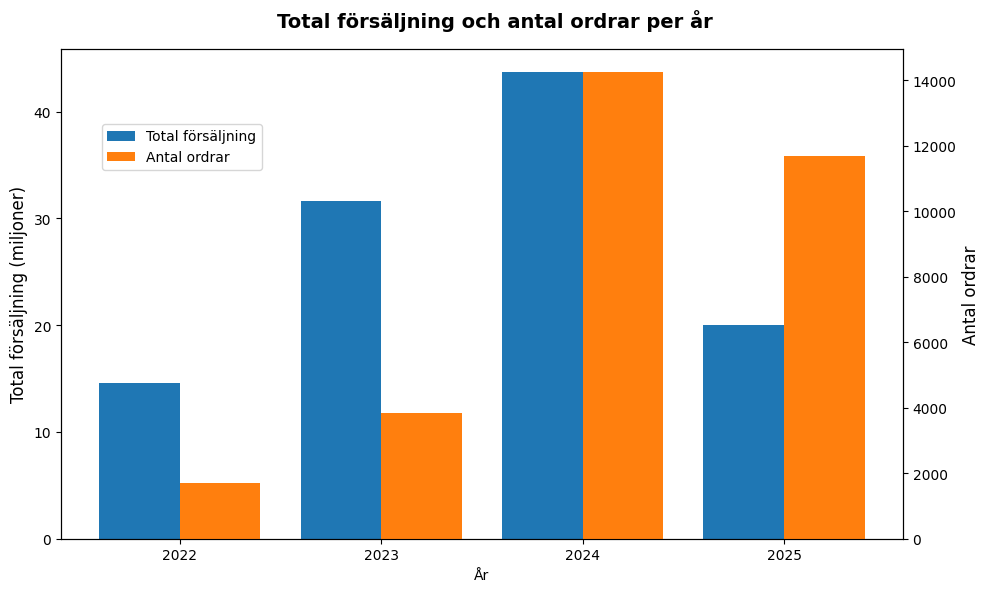

In [6]:
query_vis4 = """
SELECT
    YEAR(OrderDate) AS OrderYear,
    SUM(SubTotal) AS TotalSales,
    COUNT(DISTINCT SalesOrderId) AS NumberOfOrders
FROM Sales.SalesOrderHeader
GROUP BY YEAR(OrderDate)
ORDER BY OrderYear;
"""

df_vis4 = query_df(query_vis4)
df_vis4['TotalSales_M'] = df_vis4['TotalSales'] / 1e6

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

x = np.arange(len(df_vis4['OrderYear']))
width = 0.4

# TotalSales (vänster y-axel)
bars1 = ax1.bar(
    x - width/2,
    df_vis4['TotalSales_M'],
    width=width,
    color='tab:blue',
    label='Total försäljning'
    )

bars2 = ax2.bar(
    x + width/2,
    df_vis4['NumberOfOrders'],
    width=width,
    color='tab:orange',
    label='Antal ordrar'
)
ax1.set_ylabel('Total försäljning (miljoner)', fontsize=12)
ax2.set_ylabel('Antal ordrar', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(df_vis4['OrderYear'])
ax1.set_xlabel('År')
fig.suptitle('Total försäljning och antal ordrar per år', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.8))
plt.tight_layout()
plt.show()



### Insikter - Försäljning och antal ordrar per år
2024 är året med högst försäljning och flest ordrar. Både försäljning och antal ordrar ökar från 2022 till 2024.

Finns inte fullständig data från 2022 och 2025. Troligtvis därför försäljning ser ut att ha minskat så kraftigt från 2024 till 2025. 

## Visualisering 5: Top 10 produkter
Vilka 10 produkter genererar mest försäljning?

Tabell som används: 
Sales.SalesOrderDetail
Production.Product

Plan: 
JOINA tabellerna    
Använd OrderQty och UnitPrice för att räkna ihop inkomst per produkt    
Välj ut topp 10   
Skapa liggande stapeldiagram     
Analysera resultatet

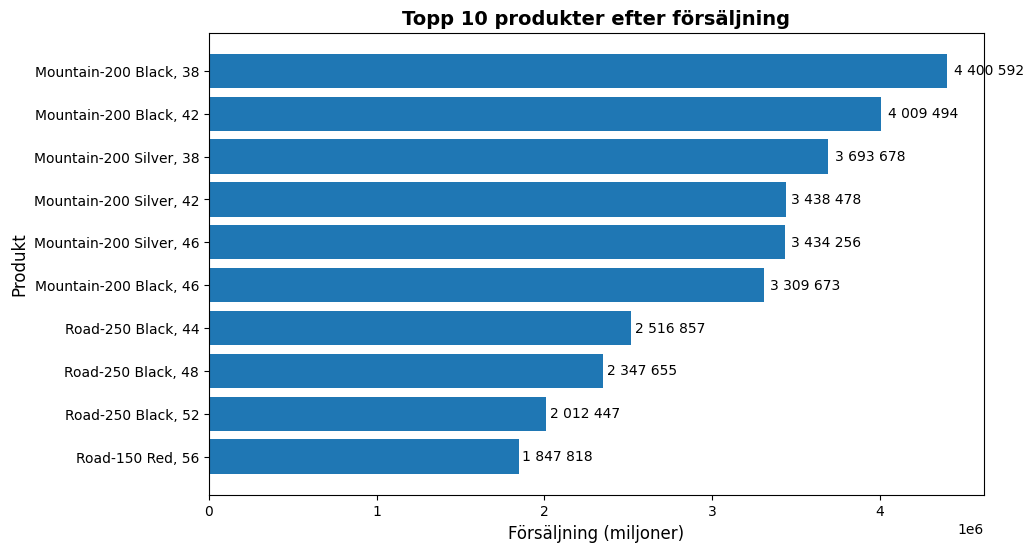

In [29]:
query_vis5 = """
SELECT TOP 10
    p.Name AS ProductName,
    SUM(sod.OrderQty * sod.UnitPrice * (1 - sod.UnitPriceDiscount)) AS TotalSales
FROM Sales.SalesOrderDetail sod
INNER JOIN Production.Product p ON sod.ProductID = p.ProductID
GROUP BY p.Name
ORDER BY TotalSales DESC;
"""

df_vis5 = query_df(query_vis5)

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(df_vis5['ProductName'], df_vis5['TotalSales'])
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + width * 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}'.replace(',', ' '),
        va='center'
    )
ax.invert_yaxis()
ax.set_xlabel('Försäljning (miljoner)', fontsize=12)
ax.set_ylabel('Produkt', fontsize=12)
ax.set_title('Topp 10 produkter efter försäljning', fontsize=14, fontweight='bold')
plt.show()


### Insikter - Topp 10 produkter
Cyklar är den kategorien som tydligt dominerar i försäljningsintäkter. 

Mountain-200 black, 38 ligger i topp med intäkt på 4 400 592 kr.

## Visualisering 6: Försäljning och antal kunder per region
Hur skiljer sig försäljning mellan olika regioner och hur många unika kunder har varje region?

Tabell som används: 
Sales.SalesOrderHeader   
Sales.SalesTerritory    
Sales.Customer   

Plan: 
JOINA tabellerna    
SUM försäljning    
COUNT för CustomerID   
Skapa grupperat stapeldiagram   
Analysera resultatet

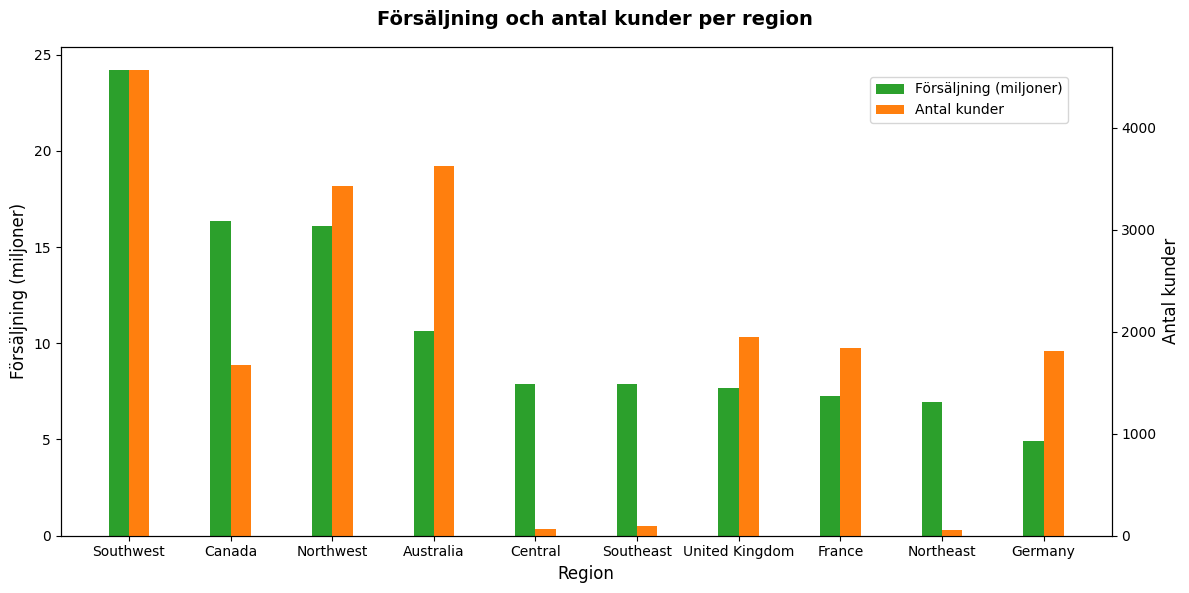

In [30]:
query_vis6 = """
SELECT
    st.Name AS Region,
    SUM(soh.SubTotal) AS Sales,
    COUNT(DISTINCT c.CustomerID) AS NumberOfCustomers
FROM Sales.SalesTerritory st  
INNER JOIN Sales.Customer c ON st.TerritoryID = c.TerritoryID
INNER JOIN Sales.SalesOrderHeader soh ON c.CustomerID = soh.CustomerID
GROUP BY st.Name
ORDER BY Sales DESC;
"""

df_vis6 = query_df(query_vis6)

df_vis6['Sales_M'] = df_vis6['Sales'] / 1e6

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

x = np.arange(len(df_vis6['Region']))
width = 0.2

bars1 = ax1.bar(
    x - width/2,
    df_vis6['Sales_M'],
    width=width,
    color='tab:green',
    label='Försäljning (miljoner)'
    )

bars2 = ax2.bar(
    x + width/2,
    df_vis6['NumberOfCustomers'],
    width=width,
    color='tab:orange',
    label='Antal kunder'
)
ax1.set_ylabel('Försäljning (miljoner)', fontsize=12)
ax2.set_ylabel('Antal kunder', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(df_vis6['Region'])
ax1.set_xlabel('Region', fontsize=12)
fig.suptitle('Försäljning och antal kunder per region', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.show()

### Insikter - Försäljning och antal kunder per region

Southwest är tydligt den starkaste regionen. Den har både högst försäljning (över 20 miljoner) och den flest kunder (över 4000 st). 

Tyskland hade den lägsta försäljning trots att de ha ett relativt många kunder. 

Kanada har höga ordervärden där varje kund i snitt spenderar mer per person. Medan Australien har många kunder men inte lika höga ordervärden. 

Central och Southeast är troligtvis beroende av några få storkunder som spenderar mycket. Om en enda kund lämna, tappar troligtvis regionen nästan hela sin omsättning. 

## Visualisering 7: Genomsnittligt ordervärde per region och kundtyp
Vilka regioner har högst/lägst genomsnittligt ordervärde, och skiljer det sig mellan individuella kunder och företagskunder?

Tabell som används: 
Sales.SalesOrderHeader   
Sales.SalesTerritory    
Sales.Customer 
Sales.Store  

Plan: 
JOINA tabellerna    
CASE när StoreId är NULL/NOT NULL     
SUM SubTotal och dividera med COUNT SalesOrderID    
Skapa grupperat stapeldiagram   
Analysera resultatet

Text(0.5, 0.98, '')

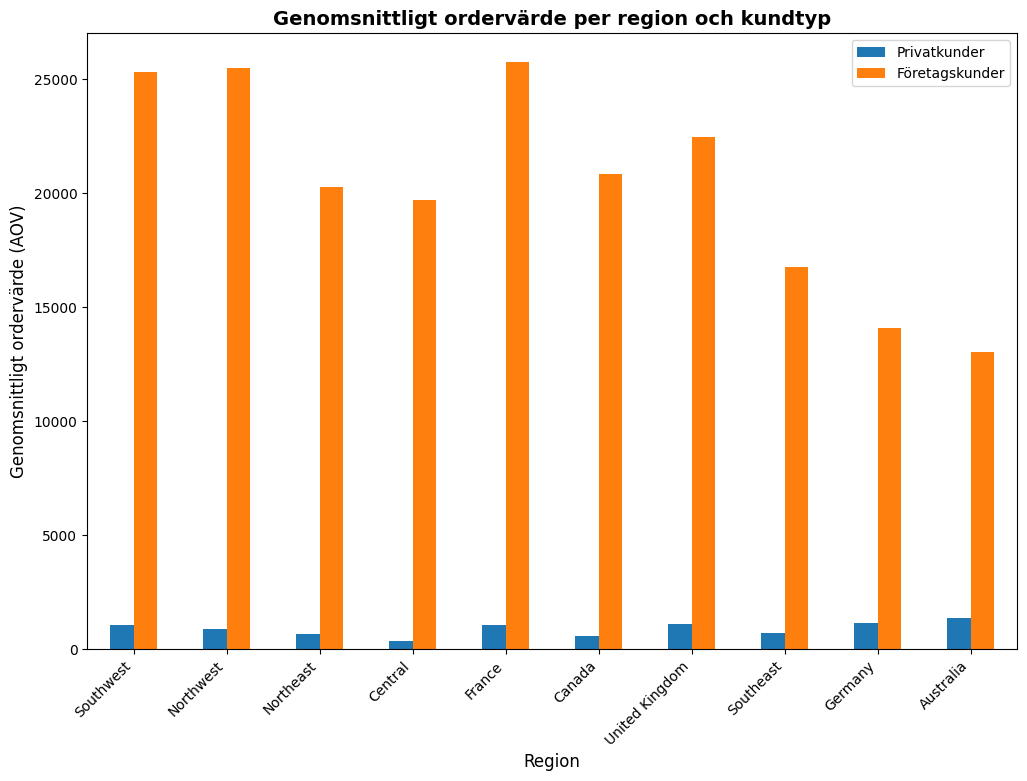

In [31]:
query_vis7 = """
SELECT
    st.Name AS Region,
    SUM(CASE WHEN c.StoreID IS NULL THEN soh.SubTotal END) 
    / COUNT(CASE WHEN c.StoreID IS NULL THEN soh.SalesOrderID END) AS AOV_Individual,
    SUM(CASE WHEN c.StoreID IS NOT NULL THEN soh.SubTotal END) 
    / COUNT(CASE WHEN c.StoreID IS NOT NULL THEN soh.SalesOrderID END) AS AOV_Store
FROM Sales.SalesOrderHeader soh 
INNER JOIN Sales.SalesTerritory st ON soh.TerritoryID = st.TerritoryID
INNER JOIN Sales.Customer c ON soh.CustomerID = c.CustomerID
LEFT JOIN Sales.Store s ON soh.SalesPersonID = s.SalesPersonID
GROUP BY st.Name
ORDER BY (SUM(soh.SubTotal) / COUNT(soh.SalesOrderID)) DESC;
"""

df_vis7 = query_df(query_vis7)

take = df_vis7[['Region', 'AOV_Individual', 'AOV_Store']].copy()

ax = take.plot(
    x='Region', 
    y=['AOV_Individual', 'AOV_Store'], 
    kind="bar", 
    figsize=(12,8), 
    width=0.5)

ax.set_title('Genomsnittligt ordervärde per region och kundtyp', fontsize=14, fontweight='bold')
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Genomsnittligt ordervärde (AOV)', fontsize=12)
ax.legend(['Privatkunder', 'Företagskunder'],)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.suptitle('')


### Insikter - Genomsnittligt ordervärde per region och kundtyp

Företagskunder har genomgående ett mycket högre genomsnittligt ordervärde jämfört med privatkunder.

Nivån skiljer sig något mellan regioner men mönstret är detsamma överallt: företagskunder har göra genomsnittligt ordervärde.

Frankirke, Northwest och Sounthwest sticker ut med mycket höga ordervärden för företag. Australien och Tyskland har lägst ordervärden för företag. 

Privatkundernas ordervärden ligger relativt samtal men men något högre nivåer i Australien och Tyskland. Där har det kanske varit mer fokus på privatkunder jämfört med företagskunder. 

## Produktportfölj-analys
- Vilka produkter är "winners"?
- Vilka produkter är losers?
- Vilka produkter bör vi sluta sälja och vilka bör vi satsa på?
- Finns det produkter hög kvalitet men låg intäkt?

Tabell som används:   
Sales.SalesOrderDetail   
Production.Product     
Production.ProductCostHistory    
Production.ProductSubCatagory    
Production.ProductCategory    

Plan: 
JOINA tabellerna    
Räkna ut vilka produkter som har bäst försäljning i kombination med bäst marginal ("Winners"). Visualiera med stapeldiagram.    
Räkna ut vilka produkter som har sämst försäljning i kombination med lägst marginal ("losers"). Visualiera med stapeldiagram.     
Pivottabell med Kategorier och produkter och deras försäljning och vinst.     
Scatterplot med Försäljning och marginal.   
Räkna ut försäljning, vinst och marginal för respektive kategori. Visualisera med stapeldiagram.    
Analysera resultatet

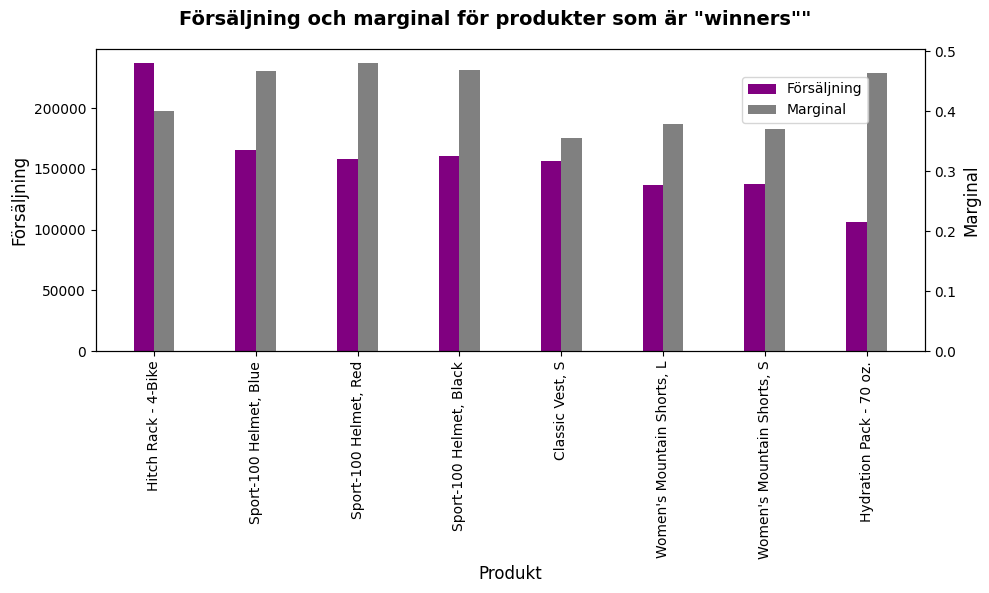

In [32]:
query_vis8 = """
SELECT
    p.Name AS ProductName,
    SUM(sod.LineTotal) AS Revenue,
    SUM(sod.LineTotal) - SUM(sod.OrderQty * pch.StandardCost) AS Profit,
    (SUM(sod.LineTotal) - SUM(sod.OrderQty * pch.StandardCost)) 
        / SUM(sod.LineTotal) AS Margin
FROM Sales.SalesOrderDetail sod
JOIN Production.Product p ON sod.ProductID = p.ProductID
JOIN Production.ProductCostHistory pch ON p.ProductID = pch.ProductID
WHERE pch.EndDate IS NULL
GROUP BY p.Name
HAVING 
    SUM(sod.LineTotal) > 100000
    AND (SUM(sod.LineTotal) - SUM(sod.OrderQty * pch.StandardCost)) 
        / SUM(sod.LineTotal) > 0.3
ORDER BY Profit DESC;
"""

df_vis8 = query_df(query_vis8)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

x = np.arange(len(df_vis8['ProductName']))
width = 0.2

bars1 = ax1.bar(
    x - width/2,
    df_vis8['Revenue'],
    width=width,
    color='purple',
    label='Försäljning'
    )

bars2 = ax2.bar(
    x + width/2,
    df_vis8['Margin'],
    width=width,
    color='gray',
    label='Marginal'
)
ax1.set_ylabel('Försäljning', fontsize=12)
ax2.set_ylabel('Marginal', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(df_vis8['ProductName'], rotation=90)
ax1.set_xlabel('Produkt', fontsize=12)
fig.suptitle('Försäljning och marginal för produkter som är "winners""', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()


### Motivering

Denna query är utformad för att identifiera produkter som:
- Har hög omsättning
- Genererar hög vinst
- Har stark marginal

Valde att göra stapeldiagram med parallella staplar för att tydligt se hur försäljning och marginar hör ihop/skiljer sig. 

### Insikter

- Hitch Rack - 4 en storsäljare som har högst försäljning och en marginal på ca 40 %. 
- Hjälmar (Sport-100 i olika färger) har något lägre försäljning men högre marginal på 50 %. 
- Eftersom marginalen är såpass stor för hjälmarna kan det vara produkter som är värda att satsa mer på i marknadsföring. 

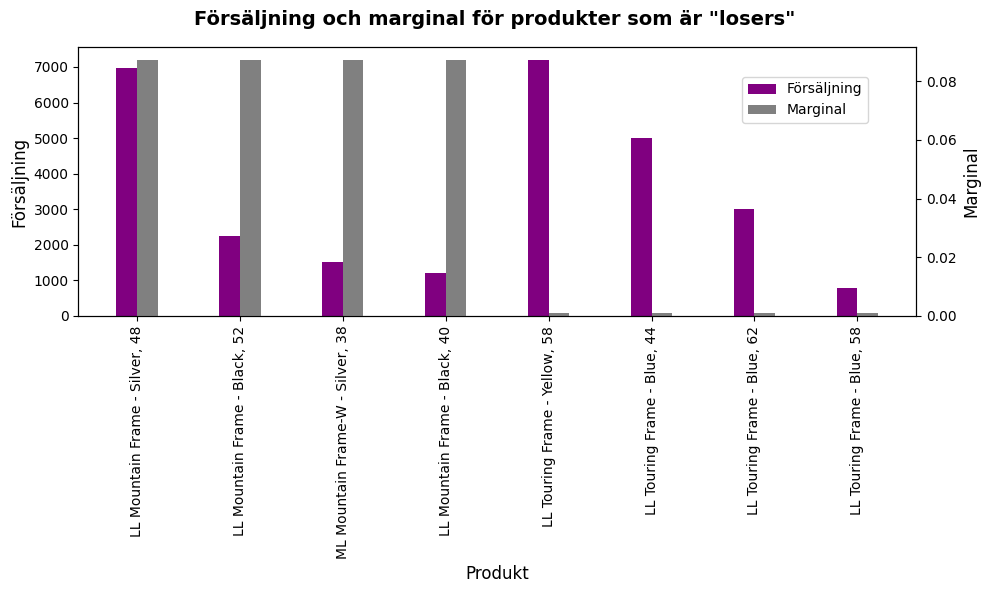

In [33]:

query_vis9 = """
SELECT
    p.Name AS ProductName,
    SUM(sod.LineTotal) AS Revenue,
    SUM(sod.LineTotal) - SUM(sod.OrderQty * pch.StandardCost) AS Profit,
    (SUM(sod.LineTotal) - SUM(sod.OrderQty * pch.StandardCost)) 
        / SUM(sod.LineTotal) AS Margin
FROM Sales.SalesOrderDetail sod
JOIN Production.Product p ON sod.ProductID = p.ProductID
JOIN Production.ProductCostHistory pch ON p.ProductID = pch.ProductID
WHERE pch.EndDate IS NULL
GROUP BY p.Name
HAVING 
    SUM(sod.LineTotal) < 10000
    AND (SUM(sod.LineTotal) - SUM(sod.OrderQty * pch.StandardCost)) 
        / SUM(sod.LineTotal) < 0.2
ORDER BY Profit DESC;
"""

df_vis9 = query_df(query_vis9)

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

x = np.arange(len(df_vis8['ProductName']))
width = 0.2

bars1 = ax1.bar(
    x - width/2,
    df_vis9['Revenue'],
    width=width,
    color='purple',
    label='Försäljning'
    )

bars2 = ax2.bar(
    x + width/2,
    df_vis9['Margin'],
    width=width,
    color='gray',
    label='Marginal'
)
ax1.set_ylabel('Försäljning', fontsize=12)
ax2.set_ylabel('Marginal', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(df_vis9['ProductName'], rotation=90)
ax1.set_xlabel('Produkt', fontsize=12)
fig.suptitle('Försäljning och marginal för produkter som är "losers"', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

### Motivering

Denna query är utformad för att identifiera produkter som:
- Har låg omsättning
- Genererar lite vinst
- Har liten marginal

Valde att göra stapeldiagram med parallella staplar för att tydligt se hur försäljning och marginar hör ihop/skiljer sig. 

### Insikter

- Produkter med både låg försäljning och marginar är LL Touring Frame Yellow 58, LL Touring Frame Blue 44 och 62 och 58.
- Det kan vara produkter som helt tas bort ur sortimentet. 

In [35]:
query_vis10 = """
SELECT
    p.Name AS ProductName,
    pc.Name AS Category,
    SUM(sod.OrderQty) AS TotalQuantity,
    SUM(sod.LineTotal) AS Revenue,
    SUM(sod.OrderQty * pch.StandardCost) AS Cost,
    SUM(sod.LineTotal) - SUM(sod.OrderQty * pch.StandardCost) AS Profit,
    CASE  
        WHEN SUM(sod.LineTotal) = 0 THEN 0
        ELSE (SUM(sod.LineTotal) - SUM(sod.OrderQty * pch.StandardCost)) / SUM(sod.LineTotal)
        END AS Margin
FROM Sales.SalesOrderDetail sod 
INNER JOIN Sales.SalesOrderHeader soh ON sod.SalesOrderID = soh.SalesOrderID
INNER JOIN Production.Product p ON sod.ProductID = p.ProductID
INNER JOIN Production.ProductSubcategory psc ON p.ProductSubcategoryID = psc.ProductSubcategoryID
INNER JOIN Production.ProductCategory pc ON pc.ProductCategoryID = psc.ProductCategoryID
INNER JOIN Production.ProductCostHistory pch ON p.ProductID = pch.ProductID
WHERE pch.EndDate IS NULL
GROUP BY p.Name, pc.name
ORDER BY Profit DESC;
"""

df_vis10 = query_df(query_vis10)

pivot_cat = pd.pivot_table(
    df_vis10,
    index=['Category', 'ProductName'],
    values=['Revenue', 'Profit'],
    aggfunc='sum'
)

pivot_cat = pivot_cat.sort_values(
    by=['Category', 'Profit'],
    ascending=[True, False]
)

pivot_cat



Profit        Revenue
Category    ProductName                                              
Accessories Hitch Rack - 4-Bike           95006.076000  237096.156000
            Sport-100 Helmet, Blue        77165.696149  165406.617049
            Sport-100 Helmet, Red         75773.638592  157772.394392
            Sport-100 Helmet, Black       75389.806236  160869.517836
            Hydration Pack - 70 oz.       49042.864034  105826.418334
...                                                ...            ...
Components  HL Road Frame - Black, 44    -23676.120600  375026.977200
            LL Road Frame - Black, 52    -23916.760134  299595.522966
            HL Road Frame - Red, 44      -26973.521900  395182.699300
            HL Road Frame - Red, 62      -27032.014600  394255.572400
            ML Road Frame-W - Yellow, 44 -32252.371051  485700.546949

[183 rows x 2 columns]

### Motivering
Denna query och pivottabell hjälper oss att se vilka kategorier som:
- Driver mest vinst
- Har högst marginal
- Omsätter mycket men har låg lönsamhet    

Den hjälper oss också att se vilka produkter som är "winners" och "losers" i respektive kategori.     

#### Produkter med högst vinst i respektive kategori:
- Accessoarer: Hitch Rack och Sport-100 hjälmar i olka färger. 
- Cyklar: Mountain-200 black i olika storlekar.
- Kläder: Classic Vest (stl: S-L) och Women's mountain shorts (stl: S-L).
- Komponenter: HL Crankset, HL Maintain frame silver/black i olika storlekar.

#### Produkter med lägst vinst i respektive kategori:
- Accessoarer: Road tire tube, Patch kit/8 patch och Touring tire tube. 
- Cyklar: Touring-1000 Yellow och Touring-3000 blue/yellow.
- Kläder: Short-sleeve classic jersey och Long-sleeve logo jersey.
- Komponenter: HL Road frame-red 44'/62' och ML Road Frame-W yellow 44'

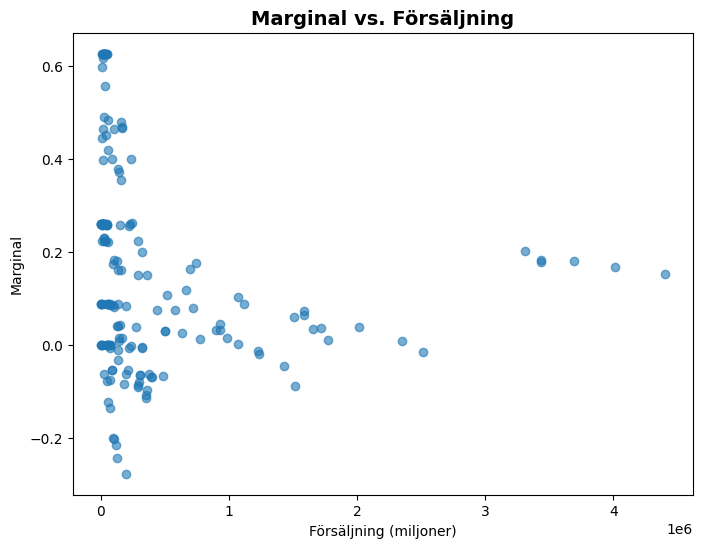

In [36]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(df_vis10['Revenue'], df_vis10['Margin'], alpha=0.6)
ax.set_title('Marginal vs. Försäljning', fontsize=14, fontweight='bold')
ax.set_xlabel('Försäljning (miljoner)')
ax.set_ylabel('Marginal')
plt.show()

### Motivering

Väljer att visualisera relationen mellan marginal och försäljning med scatter plot för att kunna se om det finns en korrelation.    
Vi kan se på gruppnivå hur relationen ser ut mellan marginal och försälning.   

### Insikter

- Visualiseringen visar att hög försäljning inte nödvändigtvis sammanfaller med hög lönsamhet. 
- Sortimenten innehåller många produkter som har låga försäljningvolymer. 
- Vi ser också att marginalerna variera kraftigt (från ca -25% till 60%). 
- Inga produkter som säljs i stora volymer har extremt hög marginal. 

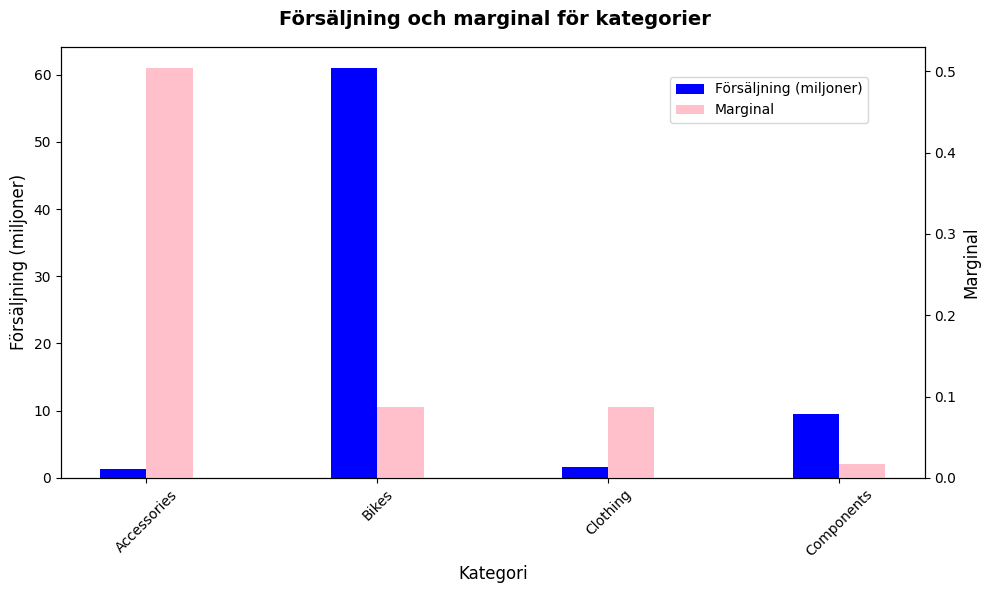

In [38]:
df_vis10_cat = (df_vis10
                .groupby('Category')
                .agg(
                    TotalQuantity=('TotalQuantity', 'sum'),
                    Revenue=('Revenue', 'sum'),
                    Profit=('Profit', 'sum'),
                ).reset_index()
                )
df_vis10_cat['Margin'] = (df_vis10_cat['Profit'] / df_vis10_cat['Revenue'])

df_vis10_cat['Revenue_M'] = df_vis10_cat['Revenue'] / 1e6

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

x = np.arange(len(df_vis10_cat['Category']))
width = 0.2

bars1 = ax1.bar(
    x - width/2,
    df_vis10_cat['Revenue_M'],
    width=width,
    color='blue',
    label='Försäljning (miljoner)'
    )

bars2 = ax2.bar(
    x + width/2,
    df_vis10_cat['Margin'],
    width=width,
    color='pink',
    label='Marginal'
)
ax1.set_ylabel('Försäljning (miljoner)', fontsize=12)
ax2.set_ylabel('Marginal', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(df_vis10_cat['Category'], rotation=45)
ax1.set_xlabel('Kategori', fontsize=12)
fig.suptitle('Försäljning och marginal för kategorier', fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

### Motivering

Tidigare visualisering för kategorier tittade enabrt på försäljning. Att lägga till marginal ger extra information till exempel har accessorier låg försäljning men hög margin vilket gör att det kan var en kategori att satsa på. 

### Insikter
- Av de fyra kategorierna är det cyklar som tydligt har högst försäljningsvärde. 
- Accessoarer har bäst marginal. 
- Kläder och Komponenter kan vara kategorier som vi borde skära ner på då försäljning och marginalen är dålig. 

## Sammanfattande slutsatser

Företagets försäljning och lönsamhet drivs av ett relativt litet antal starka produkter, kategorier och regioner samtidigt som sortimenten innehåller många produkter med låg volym och varierande lönsamhet.   

Sortimenten är tydligt fokuserat på komponenter med det är cyklar som står för det högsta försäljningsvärdet och accessoarer som uppvisar bäst margina. Detta indikerar att framtisa tillväxt inte enabart bör fokusera på volym utan på produkter och kategorier med stark lönsamhet. Kläder och komponenter framstår som områden där sortimentet kan behöva reduceras eller starkt optimeras.    

Försäljningen uppvisar en tydlig positiv trend över tid med 2024 som starkaste år. Det finns tecken på säsongsvariation som kan användas för bättre planering av kampanjer och lager.    

Regionen Southwest är företagets viktigaste marknad, både sett till försäljning och kundbas. Analysen visar även tydliga skillnader i kundbeteende mellan regionerdär vissa marknader är beroende av ett fåtal storkunder vilket innebär ökad affärsrisk. 


Företagskunder har genomgående ett betydligt högre genomsnittligt ordervärde jämfört med privatkunder i samtliga regioner. Det kan vara lönsamt att vidareutveckla försäljningen till företag.    

På produktnivå ser man att hög försäljning inte nödvändigtvis innebär hög lönsamhet. Produkter som Hitch Rack och Sport-100-hjälmar utmärker sig genom en kombination av hög försäljning och mycket hög marginal och bör prioriteras framöver. Samtidigt identifieras flera produkter med låg försäljning och negativ marginal vilka kan vara aktuella att avveckla. 